# Welcome to the **kids** triage game
In this game, you'll get a case of a kid who doesn't want to go to school. Your task is to find out if they are actually sick or not. You'll get either an image (if they think they have a broken arm) or health data (like temperature...etc)

⚽️⚽️ The more kids you classify correctly -> the more point you get


<div>
<img src="https://drive.google.com/uc?id=1zJB5PrWiKvqUd-khXmkL_7IpLgnQU1ah" width="500"/>
</div>

**Lets write together**

# Install and imports

In [ ]:
# install gdown to download the data
!pip install gdown

# Downloade the data
!gdown https://drive.google.com/uc?id=1Dm5FHRIJEblaB5U0aQxJwJuhVOZBWaGT

# unzip the data ---> important to learn
!unzip -q kids_imgs.zip

Downloading...
From: https://drive.google.com/uc?id=1Dm5FHRIJEblaB5U0aQxJwJuhVOZBWaGT
To: /content/kids_imgs.zip
100% 1.94M/1.94M [00:00<00:00, 51.4MB/s]


In [ ]:
import numpy as np
import os

import matplotlib.pyplot as plt
from pprint import pprint

from tqdm import tqdm

from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score, accuracy_score

import seaborn as sns


# Loaders

Number of images: 4


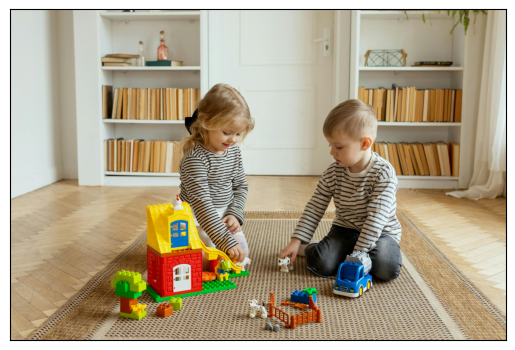

In [ ]:
class ImgLoader:
  def __init__(self, path):
    self.path = path
    self._number_of_imgs = len(os.listdir(path)) #len of images on the path

  def __len__(self):
    return self._number_of_imgs

  def __getitem__(self, idx):
    image_name = os.listdir(self.path)[idx]
    return plt.imread(os.path.join(self.path, image_name))

def plot(img):
  fig, ax = plt.subplots()
  ax.imshow(img)
  ax.axes.get_xaxis().set_ticks([])
  ax.axes.get_yaxis().set_ticks([])
  # show the image



# Test
img_loader = ImgLoader("kids_imgs/imgs")
print(f"Number of images: {len(img_loader)}")

# # plot to test
img = img_loader[0]
plot(img)


In [ ]:
# Lets cheat and write the other kids in the code

class HealthLoader:
  def __init__(self):
    self.data = [
        {
            "temp_c": 40,
            "can_see": True,
            "can_hear": True,
            "is_bleeding": False
        },
        {
            "temp_c": 37,
            "can_see": True,
            "can_hear": True,
            "is_bleeding": True
        },
        {
            "temp_c": 37.3,
            "can_see": True,
            "can_hear": True,
            "is_bleeding": False
        },
        {
            "temp_c": 36.9,
            "can_see": True,
            "can_hear": True,
            "is_bleeding": False
        },
    ]

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    # print("in get item")
    return self.data[idx]


# Test
health_loader =  HealthLoader()#create an instance
print(f"Number of kids: {len(health_loader)}")
print(f"First kid:")
pprint(health_loader[0])

Number of kids: 4
First kid:
in get item
{'can_hear': True, 'can_see': True, 'is_bleeding': False, 'temp_c': 40}


In [ ]:
class DataLoader:
  def __init__(self, imgs_path):
    self.img_dataloader = ImgLoader(imgs_path)
    self.table_dataloader = HealthLoader()

  def __len__(self):
    return len(self.img_dataloader) + len(self.table_dataloader)

  def __getitem__(self, idx):
    if idx < len(self.img_dataloader):
      # load from img_dataloader
      return self.img_dataloader[idx]
    else:
      idx = idx - len(self.img_dataloader)
      # print("new idx", idx)
      return self.table_dataloader[idx]



# Test
data_loader = DataLoader("kids_imgs/imgs")
print(f"Number of kids: {len(data_loader)}")

assert len(data_loader) == len(img_loader)+len(health_loader)
# 4
# [imgs, imgs, imgs, imgs, t, t, t,t ]
data_loader[len(data_loader.img_dataloader)]
len(data_loader)

Number of kids: 8
in get item


8

# 👉👉 Game play now

  0%|          | 0/8 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

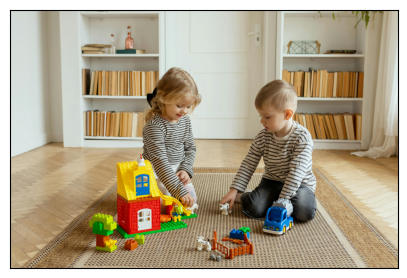

Is the kid sick? (y/n)n


 12%|█▎        | 1/8 [00:27<03:10, 27.17s/it]

<Figure size 640x480 with 0 Axes>

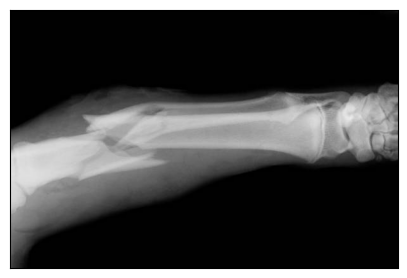

Is the kid sick? (y/n)y


 25%|██▌       | 2/8 [00:47<02:20, 23.40s/it]

<Figure size 640x480 with 0 Axes>

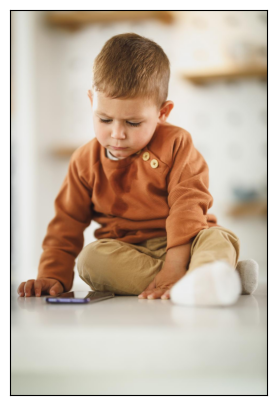

Is the kid sick? (y/n)y


 38%|███▊      | 3/8 [01:09<01:53, 22.68s/it]

<Figure size 640x480 with 0 Axes>

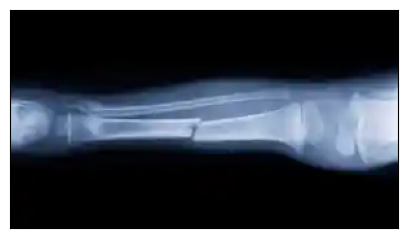

Is the kid sick? (y/n)y


 50%|█████     | 4/8 [01:21<01:13, 18.47s/it]

in get item
Kid has following symptoms
{'can_hear': True, 'can_see': True, 'is_bleeding': False, 'temp_c': 40}
Is the kid sick? (y/n)y


 62%|██████▎   | 5/8 [02:00<01:17, 25.83s/it]

in get item
Kid has following symptoms
{'can_hear': True, 'can_see': True, 'is_bleeding': True, 'temp_c': 37}
Is the kid sick? (y/n)y


 75%|███████▌  | 6/8 [02:50<01:07, 33.83s/it]

in get item
Kid has following symptoms
{'can_hear': True, 'can_see': True, 'is_bleeding': False, 'temp_c': 37.3}
Is the kid sick? (y/n)n


 88%|████████▊ | 7/8 [03:07<00:28, 28.33s/it]

in get item
Kid has following symptoms
{'can_hear': True, 'can_see': True, 'is_bleeding': False, 'temp_c': 36.9}
Is the kid sick? (y/n)n


100%|██████████| 8/8 [03:23<00:00, 25.42s/it]


In [ ]:
data = DataLoader("kids_imgs/imgs")
classifications = []

for kid_triaging in tqdm(range(len(data))):
  kid = data[kid_triaging]
  if type(kid) == np.ndarray:
    # plot(kid)
    plt.figure()
    fig, ax = plt.subplots(figsize=(5, 5))
    # plot image
    ax.imshow(kid)
    ax.axes.get_xaxis().set_ticks([])
    ax.axes.get_yaxis().set_ticks([])

    plt.show()

  else:
    print("Kid has following symptoms")
    pprint(kid)

  is_sick = input("Is the kid sick? (y/n)")
  if is_sick == "y":
    # append 1 value to classifications
    classifications.append(1)
  else:
    # append 0 value to classifications
    classifications.append(0)

with open("classifications.txt", "w") as f:
  f.write("\n".join([str(c) for c in classifications]))





# My score

In [ ]:
def load_classification():
  with open("/content/classifications.txt", "r") as f:
    lines = f.readlines()

  for idx, line in enumerate(lines):
    lines[idx] = bool(int(line.strip()))

  return lines

classifications = load_classification()
classifications

[False, True, True, True, True, True, False, False]

In [ ]:
def load_labels():
  with open("/content/kids_imgs/labels", "r") as f:
    lines = f.readlines()

  for idx, line in enumerate(lines):
    lines[idx] = bool(int(line.strip()))

  return lines


labels = load_labels()
labels

[True, True, True, False, True, True, False, False]

In [ ]:
# def accuracy(classifications, labels):
#   # implement accuracy function
#   score = 0

#   for idx, y_hat in enumerate(classifications):
#     label = labels[idx]

#     if y_hat == label:
#       score += 1

#   return score/len(labels)



def accuracy(classifications, labels):
  # implement accuracy function
  score = 0

  for y_hat, label in zip(classifications, labels):
    if y_hat == label:
      score += 1

  return score/len(labels)



accuracy(classifications, labels)

0.75

In [ ]:
for idx, class_ in enumerate(classifications):
  print(f"idx: {idx}, class: {class_}")


idx: 0, class: False
idx: 1, class: True
idx: 2, class: True
idx: 3, class: True
idx: 4, class: True
idx: 5, class: True
idx: 6, class: False
idx: 7, class: False


In [ ]:
classifications = np.array(classifications)
labels = np.array(labels)

sum(classifications==labels)/len(labels)

score = lambda x, y: (x == y).mean()

score(classifications, labels)


human_scores = [("mohannad", 1.3), ("blabla", 8), ("john", 5)]

sorted(human_scores, key=lambda t:t[1])



[('mohannad', 1.3), ('john', 5), ('blabla', 8)]

In [ ]:
# Convert boolean lists to numpy arrays if necessary
classifications = np.array(classifications)
labels = np.array(labels)


f1 = f1_score(labels, classifications)
conf_matrix = confusion_matrix(labels, classifications)
precision = precision_score(labels, classifications)
recall = recall_score(labels, classifications)
accuracy = accuracy_score(labels, classifications)

print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")


F1 Score: 0.8
Confusion Matrix:
[[2 1]
 [1 4]]
Precision: 0.8
Recall: 0.8
Accuracy: 0.75


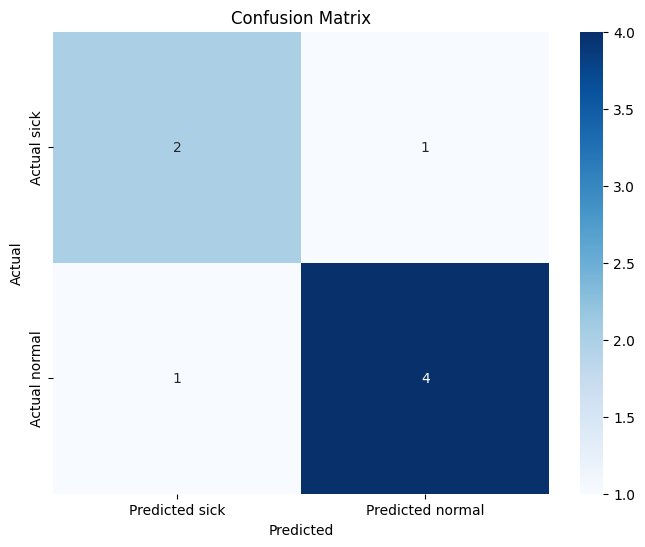

In [ ]:
plt.figure(figsize=(8, 6))
# sns heatmap
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted sick", "Predicted normal"],
            yticklabels=["Actual sick", "Actual normal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


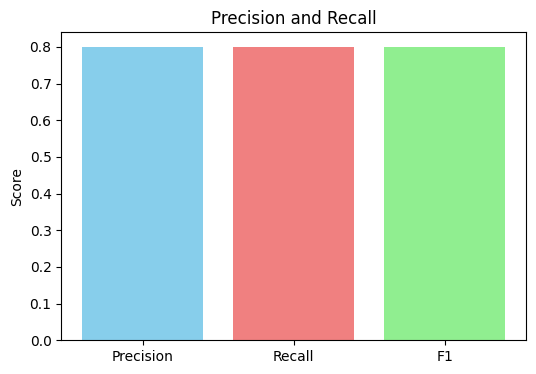

In [ ]:
# Data for the bar plot
metrics = ['Precision', 'Recall', "F1"]
scores = [precision, recall, f1]

# Create the bar plot
plt.figure(figsize=(6, 4))
# bar plot
plt.bar(metrics, scores, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylim(0, 1)  # Set y-axis limits to 0-1 for percentages
plt.ylabel('Score')
plt.title('Precision and Recall')
plt.show()
